In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../')

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [2]:
RESULTS_DIR = Path('/data/equake_results/encoding_decoding_v3/')

SESSIONS_ALL = [
    'M061_2025_03_06_14_00',
    'M061_2025_03_05_14_00',
    'M063_2025_03_13_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
    'M103_2026_02_18_15_30',
    'M106_2026_02_25_15_00',
]

EXCLUDE_AREAS = {
    'M062_2025_03_20_14_00': ['VAL'],
    'M062_2025_03_21_14_00': ['VAL'],
    'M086_2025_12_10_15_00': ['VAL'],
}

AREAS_PLOT = ['MOp', 'SSp', 'CP', 'VAL']
AREA_COLORS = {'MOp': '#7B52AE', 'SSp': '#2E8B57', 'CP': '#5B9BD5', 'VAL': '#D9534F'}
AREA_OFFSET = {'MOp': -0.3, 'SSp': -0.1, 'CP': 0.1, 'VAL': 0.3}

# Baseline window for normalization (seconds, relative to perturbation onset)
BASELINE_S = (-1.0, -0.2)

KP_ORDER_ALL = [
    'left_paw',   'left_wrist',   'left_elbow',   'left_shoulder',
    'right_paw',  'right_wrist',  'right_elbow',  'right_shoulder',
    'left_foot',  'left_ankle',   'left_knee',
    'right_foot', 'right_ankle',  'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def load_session(sess, results_dir=RESULTS_DIR):
    """Load all area files for one session.
    Returns dict {area: data_dict} and the shared time axis.
    """
    files = sorted(results_dir.glob(f'moving_win_dec_*_{sess}_npcs*.pkl'))
    if not files:
        return {}, None
    sess_data = {}
    for f in files:
        # moving_win_dec_<AREA>_<SESSION>_npcs<N>.pkl
        area = f.name.split('_')[3]
        sess_data[area] = load_pkl(f)
    # shared time axis (window centres, seconds)
    _first = next(iter(sess_data.values()))
    _first_kp = [k for k in _first if k != '_meta'][0]
    all_t = np.array(sorted(_first[_first_kp].keys()))
    return sess_data, all_t


def r2_matrix(sess_data, area, kp_order, all_t, normalize=True, baseline_s=BASELINE_S):
    """Return (n_kp, n_t) matrix of mean R² (optionally baseline-subtracted)."""
    bl_mask = (all_t >= baseline_s[0]) & (all_t < baseline_s[1])
    mat = []
    for kp in kp_order:
        if kp not in sess_data[area]:
            mat.append(np.full(len(all_t), np.nan))
            continue
        curve = np.array([sess_data[area][kp][t].mean() for t in all_t])
        if normalize:
            curve = curve - curve[bl_mask].mean()
        mat.append(curve)
    return np.array(mat)  # (n_kp, n_t)


print('Helpers loaded.')

Helpers loaded.


## Single session — heatmap (keypoints × time)

Session : M061_2025_03_06_14_00
Areas   : ['CP', 'MOp', 'SSp', 'VAL']
Window  : 0.2 s  |  step: 0.02 s
Time    : -0.90 → 1.08 s  (100 points)
Shared vmax: 0.1560
MOp: max |ΔR²| = 0.1941  post mean = -0.0742
SSp: max |ΔR²| = 0.2633  post mean = -0.0720
CP: max |ΔR²| = 0.1033  post mean = 0.0193
VAL: max |ΔR²| = 0.1402  post mean = 0.0425


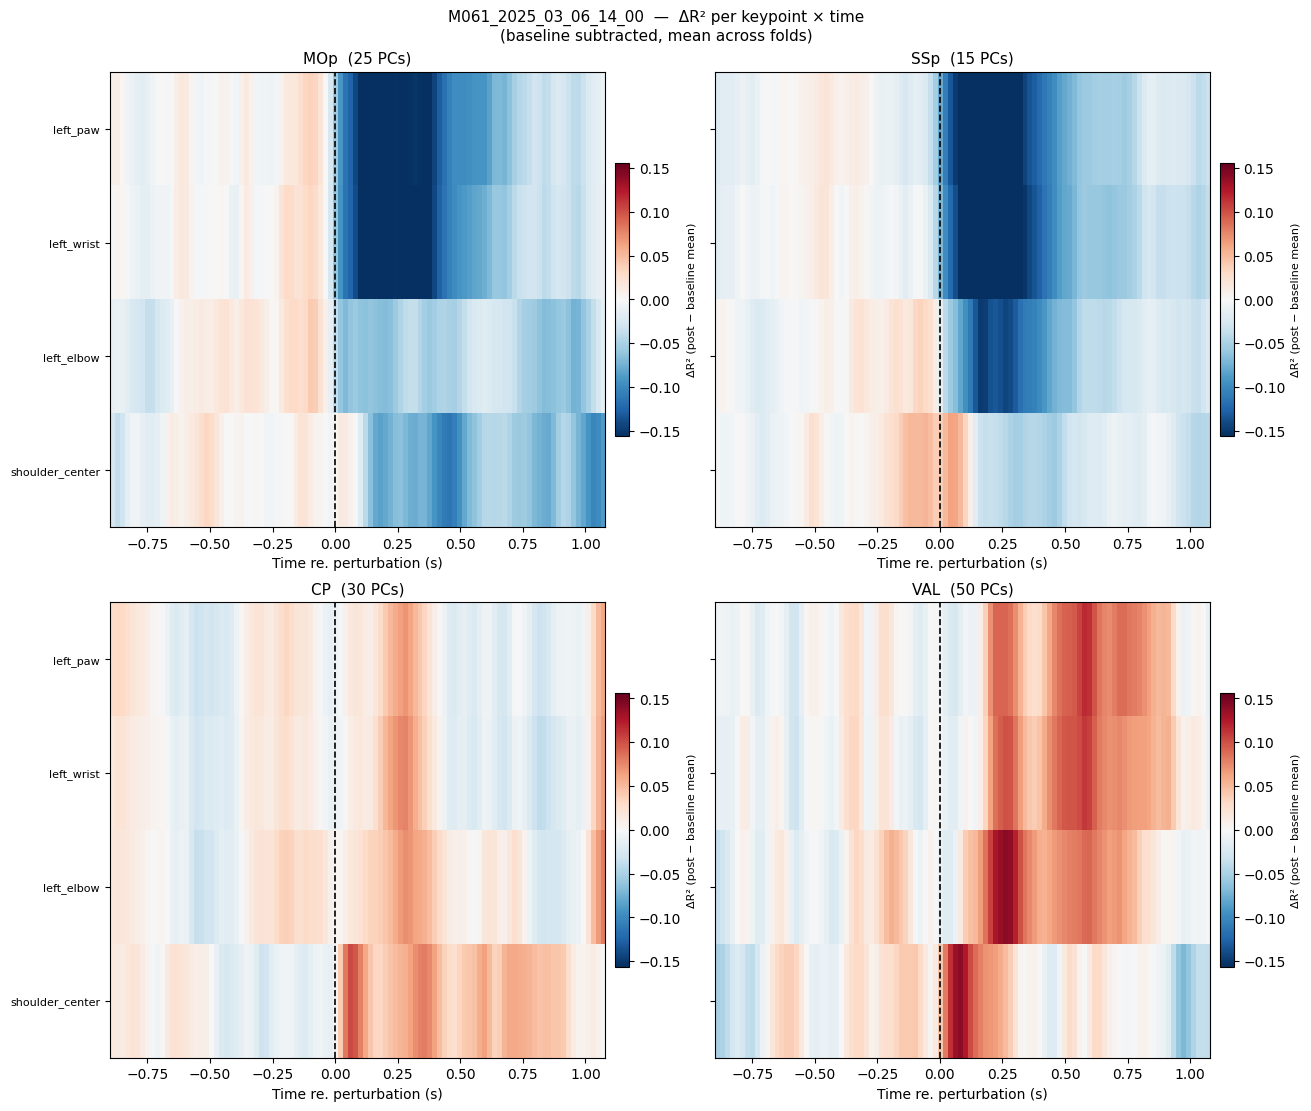

In [4]:
SESSION = 'M061_2025_03_06_14_00'

sess_data, all_t = load_session(SESSION)
if not sess_data:
    print(f'No files found for {SESSION}')
else:
    _meta0 = next(iter(sess_data.values()))['_meta']
    print(f"Session : {SESSION}")
    print(f"Areas   : {list(sess_data.keys())}")
    print(f"Window  : {_meta0['window_s']} s  |  step: {_meta0['step_s']} s")
    print(f"Time    : {all_t[0]:.2f} → {all_t[-1]:.2f} s  ({len(all_t)} points)")

    avail_areas = [a for a in AREAS_PLOT if a in sess_data]
    kp_order = [kp for kp in KP_ORDER_ALL
                if any(kp in sess_data[a] for a in avail_areas)]

    fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                             sharey=True, constrained_layout=True)

    # shared colour scale across areas
    all_vals = []
    mats = {}
    for area in avail_areas:
        m = r2_matrix(sess_data, area, kp_order, all_t, normalize=True)
        mats[area] = m
        all_vals.append(m[~np.isnan(m)])
    vmax = np.percentile(np.abs(np.concatenate(all_vals)), 97)
    print(f"Shared vmax: {vmax:.4f}")

    for ax, area in zip(axes.flat, AREAS_PLOT):
        if area not in mats:
            ax.set_title(f'{area} (no data)')
            ax.set_visible(False)
            continue
        mat = mats[area]
        n_pcs = sess_data[area]['_meta']['n_pcs']
        im = ax.imshow(mat, aspect='auto', cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax,
                       extent=[all_t[0], all_t[-1],
                                len(kp_order) - 0.5, -0.5])
        ax.axvline(0, color='k', lw=1.2, ls='--')
        ax.set_xlabel('Time re. perturbation (s)')
        ax.set_title(f'{area}  ({n_pcs} PCs)', fontsize=11)
        ax.set_yticks(range(len(kp_order)))
        ax.set_yticklabels(kp_order, fontsize=8)
        cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
        cb.set_label('ΔR² (post − baseline mean)', fontsize=8)

        _post = mat[:, all_t > 0]
        print(f"{area}: max |ΔR²| = {np.nanmax(np.abs(mat)):.4f}  "
              f"post mean = {np.nanmean(_post):.4f}")

    fig.suptitle(f'{SESSION}  —  ΔR² per keypoint × time\n(baseline subtracted, mean across folds)',
                 fontsize=11)
    plt.show()

## Cross-session grand mean heatmap

In [ ]:
# Accumulate one baseline-subtracted matrix per session per area
mats_per_area = {a: [] for a in AREAS_PLOT}
ref_t = None

for sess in SESSIONS_ALL:
    sess_data, all_t = load_session(sess)
    if not sess_data:
        print(f'  No files for {sess}, skipping')
        continue

    kp_order = [kp for kp in KP_ORDER_ALL
                if any(kp in sess_data.get(a, {}) for a in AREAS_PLOT)]
    if ref_t is None:
        ref_t = all_t

    for area in AREAS_PLOT:
        if area not in sess_data:
            continue
        if area in EXCLUDE_AREAS.get(sess, []):
            print(f'  {sess} | {area}: excluded')
            continue
        mat = r2_matrix(sess_data, area, kp_order, all_t, normalize=True)
        mats_per_area[area].append(mat)
        n_pcs = sess_data[area]['_meta']['n_pcs']
        print(f'  {sess} | {area} | {n_pcs} PCs | mat {mat.shape}')

# shared colour scale
all_vals = []
for a in AREAS_PLOT:
    for m in mats_per_area[a]:
        all_vals.append(m[~np.isnan(m)])
if all_vals:
    vmax_grand = np.percentile(np.abs(np.concatenate(all_vals)), 97)
else:
    vmax_grand = 0.1
print(f"\nShared vmax (grand mean): {vmax_grand:.4f}")

# Ensure kp_order is set from the last loaded session
kp_order_final = [kp for kp in KP_ORDER_ALL
                  if any(kp in sess_data.get(a, {}) for a in AREAS_PLOT)]

fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                         sharey=True, constrained_layout=True)

for ax, area in zip(axes.flat, AREAS_PLOT):
    stack = mats_per_area[area]
    if not stack:
        ax.set_title(f'{area} (no data)')
        ax.set_visible(False)
        continue

    grand_mean = np.nanmean(stack, axis=0)  # (n_kp, n_t)
    n_sess = len(stack)

    im = ax.imshow(grand_mean, aspect='auto', cmap='RdBu_r',
                   vmin=-vmax_grand, vmax=vmax_grand,
                   extent=[ref_t[0], ref_t[-1],
                            len(kp_order_final) - 0.5, -0.5])
    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_title(f'{area}  (n={n_sess})', fontsize=11)
    ax.set_yticks(range(len(kp_order_final)))
    ax.set_yticklabels(kp_order_final, fontsize=8)
    cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('ΔR² (post − baseline mean)', fontsize=8)

    _post = grand_mean[:, ref_t > 0]
    print(f"{area}: n={n_sess}  max |ΔR²| = {np.nanmax(np.abs(grand_mean)):.4f}  "
          f"post mean = {np.nanmean(_post):.4f}")

for ax in axes.flat[len(AREAS_PLOT):]:
    ax.set_visible(False)

fig.suptitle('Grand mean ΔR² per keypoint × time (baseline-subtracted, mean across sessions)',
             fontsize=11)
plt.show()

## Timeline per keypoint — areas overlaid

In [ ]:
# Grand mean ± SEM across sessions, one subplot per keypoint
# r2_store[area][kp] = list of (n_t,) arrays
r2_store = {a: {kp: [] for kp in kp_order_final} for a in AREAS_PLOT}

for sess in SESSIONS_ALL:
    sess_data, all_t = load_session(sess)
    if not sess_data:
        continue
    for area in AREAS_PLOT:
        if area not in sess_data or area in EXCLUDE_AREAS.get(sess, []):
            continue
        for kp in kp_order_final:
            if kp not in sess_data[area]:
                continue
            curve = np.array([sess_data[area][kp][t].mean() for t in all_t])
            bl = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
            r2_store[area][kp].append(curve - curve[bl].mean())

n_kp = len(kp_order_final)
fig, axes = plt.subplots(n_kp, 1, figsize=(10, 2.0 * n_kp),
                         sharex=True, sharey=True, constrained_layout=True)

for row, kp in enumerate(kp_order_final):
    ax = axes[row]
    for area in AREAS_PLOT:
        curves = r2_store[area][kp]
        if not curves:
            continue
        arr = np.array(curves)  # (n_sess, n_t)
        mean = arr.mean(0)
        sem  = arr.std(0) / np.sqrt(len(arr))
        col  = AREA_COLORS[area]
        label = area if row == 0 else None
        ax.plot(ref_t, mean, color=col, lw=1.2, label=label)
        ax.fill_between(ref_t, mean - sem, mean + sem, color=col, alpha=0.2)

    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
    ax.set_ylabel(kp, fontsize=7, rotation=0, ha='right', va='center', labelpad=65)

    _post_vals = {a: np.mean(r2_store[a][kp], axis=0)[ref_t > 0].mean()
                  if r2_store[a][kp] else np.nan for a in AREAS_PLOT}
    print(f"{kp:20s}  " +
          "  ".join(f"{a}={v:.4f}" for a, v in _post_vals.items()))

axes[-1].set_xlabel('Time re. perturbation (s)')
axes[0].legend(fontsize=8, frameon=False, ncol=len(AREAS_PLOT))
fig.suptitle('ΔR² per keypoint — mean ± SEM across sessions  (shading = SEM)',
             fontsize=10)
plt.show()